# Allen: fixed filters, activity history, and waveform prediction

## tl;dr
- positive, initial: later-sweep RMSE (uV), zero 469.15, offset 472.52, constant 472.57, depression 464.19, facilitation 472.43.
- positive, recovery: later-sweep RMSE (uV), zero 481.25, offset 475.51, constant 475.47, depression 448.67, facilitation 474.92.
- negative, initial: later-sweep RMSE (uV), zero 144.19, offset 157.57, constant 163.92, depression 164.84, facilitation 163.90.
- negative, recovery: later-sweep RMSE (uV), zero 266.25, offset 258.65, constant 260.43, depression 259.38, facilitation 260.33.

## Context & Methods
The question is whether a fixed effective voltage kernel explains repeated
responses, and whether depression or facilitation improves excluded outcomes.
This is retrospective development: traces were previously inspected.

### Key Assumptions
- Fit only sweeps 37–46, initial eight pulses. Source AP times condition predictions.
- Each target's pretrain [-100,-10) ms mean is available at prediction time.
- Each model learns one shared offset and amplitude from training only. No offset
  or gain is refitted to any held-out target outcome.
- The positive target has a known excitatory label; the negative target has no
  reported synapse, not an inhibitory label. The same nonnegative candidate family
  is applied to both. Database kinetics are not fitting inputs.
- Score native 50-sample (0.5 ms) means, masking command/spike-adjacent bins.
  Propagate every earlier spike through the same averaging operator.
- Depression resets to resource1 and facilitation to zero at each sweep, by assumption.
- Sweeps are repeated records of the same cells, not independent animals.

## Data


Baseline sensitivity: positive depression recovery RMSE changes from 448.67 to 481.84 uV when b is anchored to zero. The recovery advantage is not stable across these baseline assumptions; mechanistic identification remains open.

In [1]:
import hashlib,json
from pathlib import Path
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from IPython.display import Image,display
root = next(p for p in [Path.cwd(),*Path.cwd().parents]
            if (p/'verify/Q-NPF-04/allen_synphys/recovery_waveform_prediction_result.json').exists())
folder = root/'verify/Q-NPF-04/allen_synphys'
result_path = folder/'recovery_waveform_prediction_result.json'
result = json.loads(result_path.read_text(encoding='utf-8'))
def digest(p):
    with Path(p).open('rb') as stream:
        return hashlib.file_digest(stream,'sha256').hexdigest()
assert digest(folder/'recovery_waveform_prediction.py') == result['code_sha256']
assert digest(root/'tests/test_recovery_waveform_prediction.py') == result['test_sha256']
for path,sha in result['provenance']['inputs'].items():
    assert digest(root/path) == sha
for asset in result['provenance']['assets']:
    assert digest(root/asset['path']) == asset['sha256']
assert digest(root/result['arrays']['path']) == result['arrays']['sha256']
with np.load(root/result['arrays']['path'],allow_pickle=False) as archive:
    arrays = {k:archive[k] for k in archive.files}
eligible = result['provenance']['eligibility']
print('Result SHA256:',digest(result_path))
print('Included target-sweeps:',sum(r['included'] for r in eligible),'/',len(eligible))
for row in eligible:
    if not row['included']:
        print('Excluded:',row['sweep'],row['target'],'; '.join(row['reasons']))
print('Source and archive hashes verified. No new downloads.')


Result SHA256: 3d2137d5d728edf4d7f08efd3a8a280ffd7fa73ebda03a05f684ce25a6fbbad9
Included target-sweeps: 43 / 50
Excluded: 32 negative target_command_unobserved: Uncached block 627507200
Excluded: 33 negative target_command_unobserved: Uncached block 636223488
Excluded: 34 negative target_command_unobserved: Uncached block 644022272
Excluded: 35 positive source_full_gap_unobserved: Uncached block 745209856
Excluded: 35 negative source_full_gap_unobserved: Uncached block 745209856; target_command_unobserved: Uncached block 664338432
Excluded: 36 positive source_full_gap_unobserved: Uncached block 747241472; target_has_own_nonzero_command
Excluded: 36 negative source_full_gap_unobserved: Uncached block 747241472; target_command_unobserved: Uncached block 694157312
Source and archive hashes verified. No new downloads.


## Results

### Later same-cell predictions
RMSE is the square root of mean per-sweep MSE, giving each sweep equal weight.
It compares predictions with measured voltage, not isolated synaptic amplitude.
The nulls are zero change from pretrain voltage and a training-only shared offset.


In [2]:
print(f"{'Target':<10} {'Region':<10} {'Method':<14} {'RMSE/uV':>10} {'Gain vs fixed/uV2':>19} {'Improved/n':>13}")
for row in result['summary']:
    if row['cohort']!='temporal' or row['region'] not in ('initial','recovery'):
        continue
    values = []
    for sw in result['split']['temporal']:
        key = str(sw)+'_'+row['target']
        mask = arrays[key+'_'+row['region']]
        error = arrays[key+'_y'][mask]-arrays[key+'_prediction_'+row['method']][mask]
        values.append(float(np.dot(error,error)/len(error)))
    np.testing.assert_allclose(np.sqrt(np.mean(values)),row['rmse_uV'],rtol=1e-12)
    fixed = row['comparators']['constant']
    print(f"{row['target']:<10} {row['region']:<10} {row['method']:<14} {row['rmse_uV']:10.3f} "
          f"{fixed['mean_gain_uV2']:19.3f} {fixed['improved_sweeps']:>8}/{row['sweeps']:<4}")
print('Positive target, recovery across input-verified sweeps32..34:')
for sw in (32,33,34):
    rows = [r for r in result['per_sweep'] if r['sweep']==sw and r['target']=='positive' and r['region']=='recovery']
    print('Gap/ms',rows[0]['gap_ms'],{r['method']:round(np.sqrt(r['mse_uV2']),3) for r in rows})


Target     Region     Method            RMSE/uV   Gain vs fixed/uV2    Improved/n
positive   initial    zero              469.154            3213.333        6/10  
positive   initial    offset            472.519              44.559        6/10  
positive   initial    constant          472.566               0.000        0/10  
positive   initial    depression        464.190            7846.247        6/10  
positive   initial    facilitation      472.429             129.355        6/10  
positive   recovery   zero              481.250           -5528.584        5/10  
positive   recovery   offset            475.507             -34.085        5/10  
positive   recovery   constant          475.471               0.000        0/10  
positive   recovery   depression        448.671           24767.105        5/10  
positive   recovery   facilitation      474.921             522.959        8/10  
negative   initial    zero              144.193            6077.180        7/10  
negative   initi

### Held-out waveforms
These are means over sweeps47–56. Shading is between-sweep SD of observed voltage,
not a confidence interval. Masked stimulus-adjacent samples are left as gaps.
The large recovery gap separates the initial eight and final four pulses.


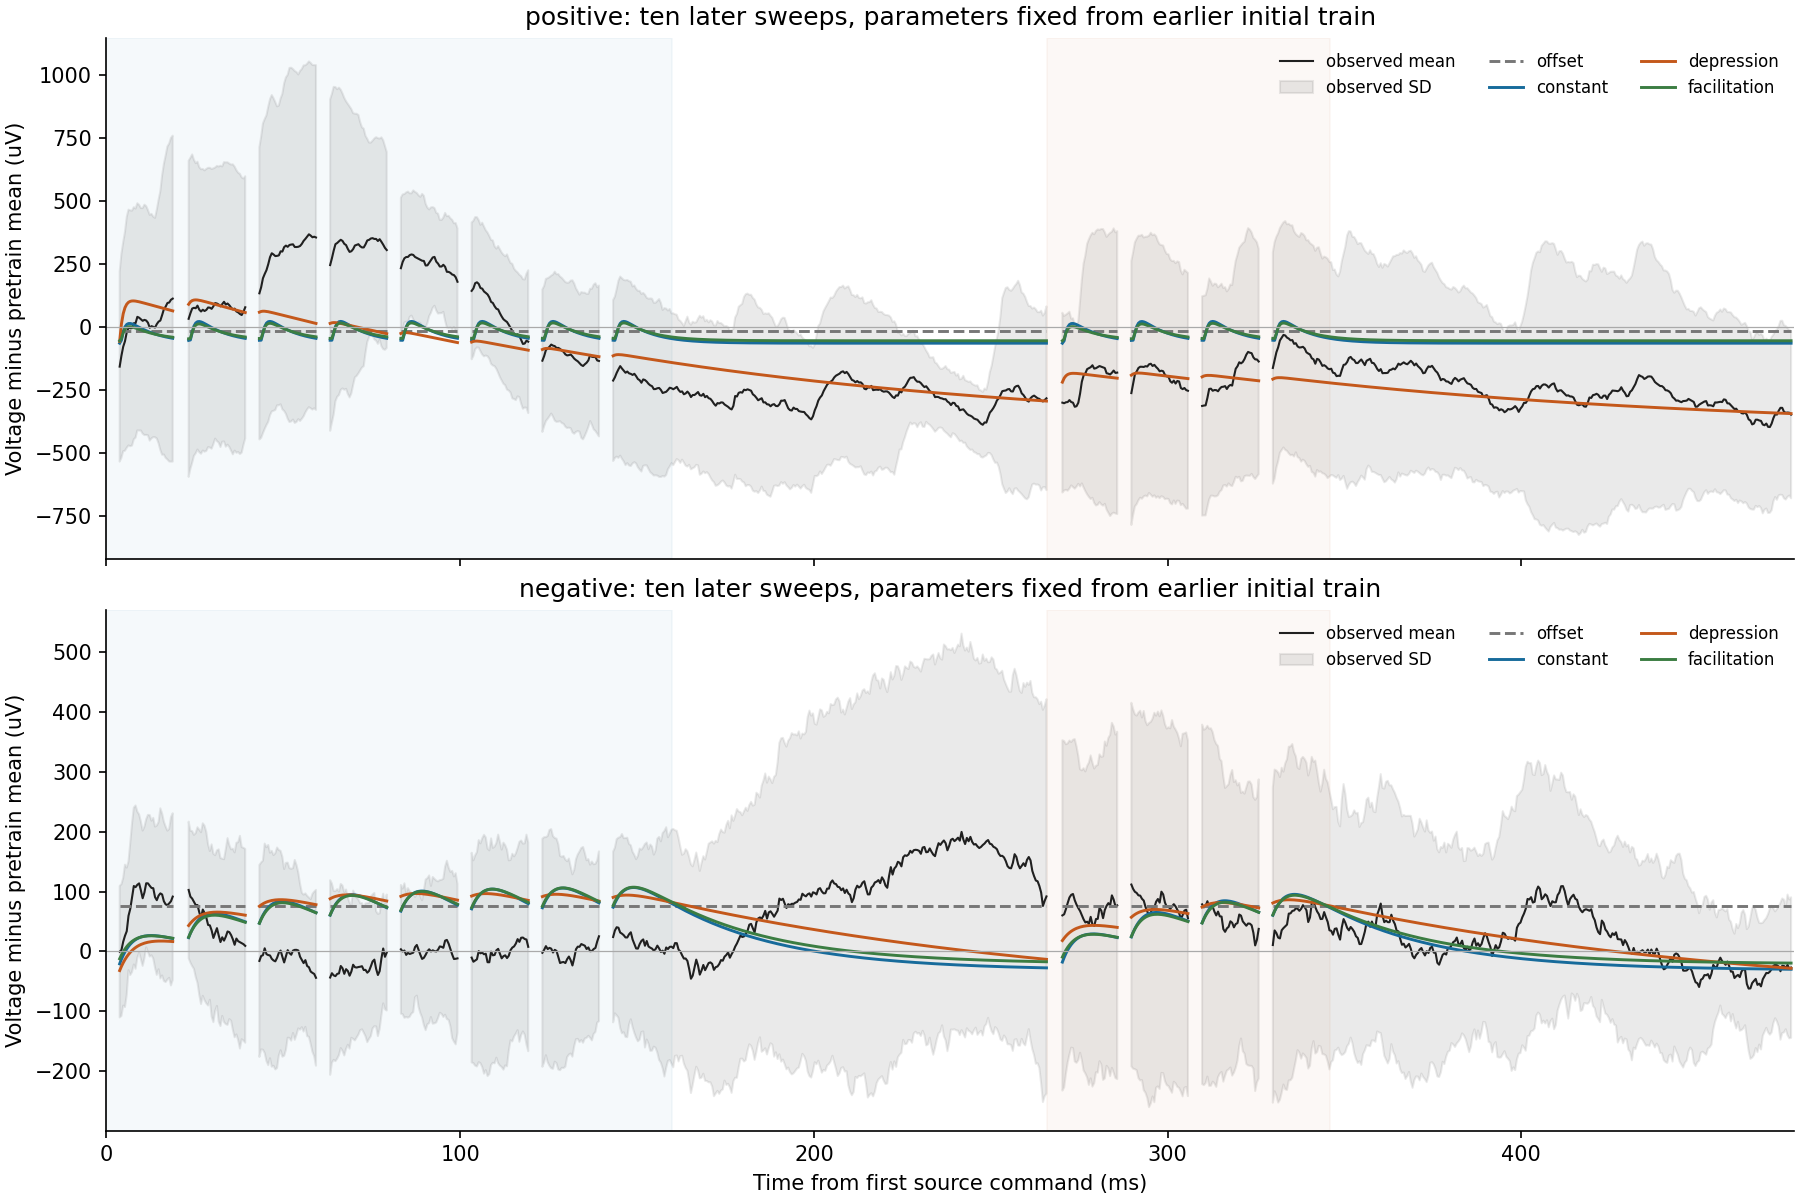

In [3]:
plt.rcParams.update({'font.size':10,'axes.spines.top':False,'axes.spines.right':False})
colors = {'offset':'#777777','constant':'#176B9B','depression':'#C4581B','facilitation':'#3B7D42'}
fig,axes = plt.subplots(2,1,figsize=(12,8),sharex=True,layout='constrained')
for ax,target in zip(axes,('positive','negative')):
    sws = result['split']['temporal']
    t = arrays[f'47_{target}_left_times']+.000245
    valid = np.logical_and.reduce([arrays[f'{sw}_{target}_valid'] for sw in sws])
    values = np.stack([arrays[f'{sw}_{target}_y'] for sw in sws])
    mean,sd = values.mean(axis=0),values.std(axis=0,ddof=1)
    ax.plot(t*1000,np.where(valid,mean,np.nan),color='#202020',linewidth=1,label='observed mean')
    ax.fill_between(t*1000,mean-sd,mean+sd,where=valid,color='#555555',alpha=.12,label='observed SD')
    for method in ('offset','constant','depression','facilitation'):
        prediction = np.mean([arrays[f'{sw}_{target}_prediction_{method}'] for sw in sws],axis=0)
        ax.plot(t*1000,np.where(valid,prediction,np.nan),color=colors[method],linewidth=1.4,
                linestyle='--' if method=='offset' else '-',label=method)
    ax.axhline(0,color='#AAAAAA',linewidth=.6)
    ax.axvspan(0,160,color='#176B9B',alpha=.04)
    ax.axvspan(266,346,color='#C4581B',alpha=.04)
    ax.set(title=f'{target}: ten later sweeps, parameters fixed from earlier initial train',ylabel='Voltage minus pretrain mean (uV)',xlim=(0,477))
    ax.legend(frameon=False,ncol=3,loc='upper right',fontsize=8)
axes[-1].set_xlabel('Time from first source command (ms)')
figure = folder/'figures/recovery_waveform_holdout.png'
figure.parent.mkdir(exist_ok=True)
fig.savefig(figure,dpi=150)
display(Image(filename=str(figure)))
plt.close(fig)


### Can the fixed-filter phase be identified from this fit?
These points are candidate kernels, not observed Fourier components. Each candidate
has its own training-only amplitude and offset. The horizontal line marks 1% extra
training MSE as a descriptive sensitivity band, not a statistical confidence set.
If fitted amplitude is zero, the output phase is undefined; a unit kernel's phase
still appears in this grid and must not be interpreted as a measured delay.


positive near-optimal phase span/degrees: -212.06357720423776 -77.23007089741988
positive selected fixed amplitude/uV: 78.72622055185423
negative near-optimal phase span/degrees: -212.06357720423776 -96.07974279462232
negative selected fixed amplitude/uV: 58.204426380414915


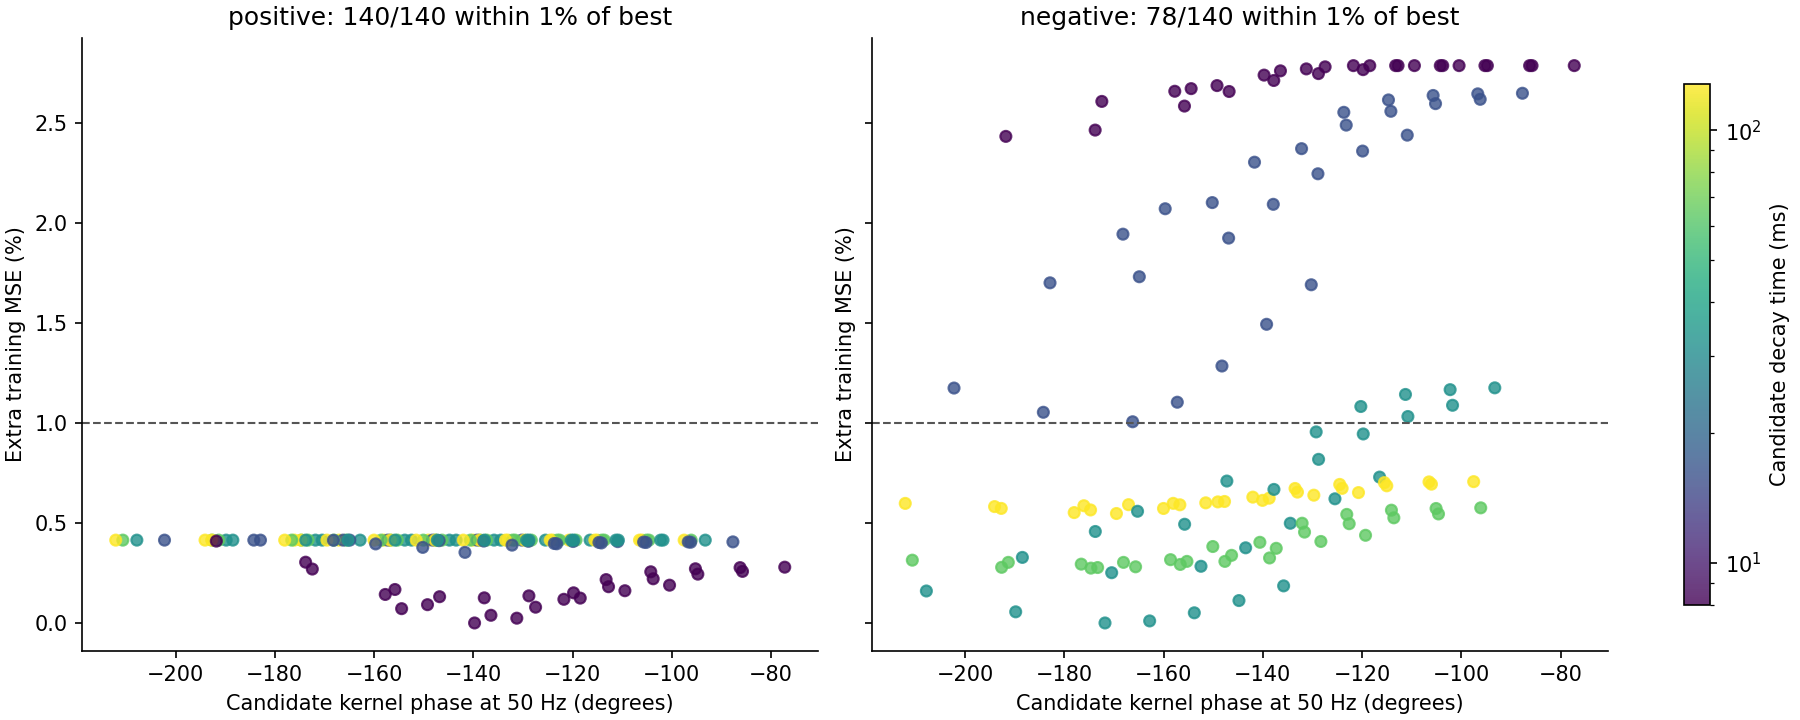

In [4]:
fig,axes = plt.subplots(1,2,figsize=(12,4.8),sharey=True,layout='constrained')
for ax,target in zip(axes,('positive','negative')):
    rows = [r for r in result['training_profiles'][target] if r['model']=='constant']
    omega = 2*np.pi*50
    phase = np.array([(-omega*r['lag_ms']/1000-np.arctan(omega*r['rise_ms']/1000)-np.arctan(omega*r['decay_ms']/1000))*180/np.pi for r in rows])
    mse = np.array([r['train_mse_uV2'] for r in rows])
    extra = 100*(mse/mse.min()-1)
    scatter = ax.scatter(phase,extra,c=[r['decay_ms'] for r in rows],norm=LogNorm(8,128),cmap='viridis',s=28,alpha=.8)
    ax.axhline(1,color='#555555',linestyle='--',linewidth=1)
    best = result['phase_diagnostics'][target]
    ax.set(title=f"{target}: {best['near_optimal_count']}/140 within 1% of best",xlabel='Candidate kernel phase at 50 Hz (degrees)',ylabel='Extra training MSE (%)')
    print(target,'near-optimal phase span/degrees:',best['near_phase_min_degrees'],best['near_phase_max_degrees'])
    print(target,'selected fixed amplitude/uV:',result['models'][target]['constant']['amplitude_uV'])
fig.colorbar(scatter,ax=axes,label='Candidate decay time (ms)',shrink=.85)
figure = folder/'figures/recovery_waveform_phase.png'
fig.savefig(figure,dpi=150)
display(Image(filename=str(figure)))
plt.close(fig)


### Post-result sensitivity to the baseline model
The selected positive depression model uses a shared -413 uV offset and a128ms
decay at the grid ceiling. After observing that result, we fit a separate b=0
variant on the exact same training split and candidate grid. This is an exploratory
sensitivity, not a second independent confirmation. Neither baseline assumption is
known to be physiologically correct.


In [5]:
sensitivity_path = folder/'recovery_offset_sensitivity_result.json'
sensitivity = json.loads(sensitivity_path.read_text(encoding='utf-8'))
assert digest(result_path) == sensitivity['parent_sha256']
assert digest(folder/'recovery_offset_sensitivity.py') == sensitivity['source_sha256']
assert digest(root/'tests/test_recovery_offset_sensitivity.py') == sensitivity['test_sha256']
assert digest(root/sensitivity['arrays']['path']) == sensitivity['arrays']['sha256']
with np.load(root/sensitivity['arrays']['path'],allow_pickle=False) as archive:
    anchored_arrays = {k:archive[k] for k in archive.files}
print(f"{'Target':<10} {'Region':<10} {'Method':<14} {'Free-b RMSE':>12} {'b=0 RMSE':>12}")
for row in sensitivity['comparisons']:
    if row['cohort']!='temporal' or row['region'] not in ('initial','recovery'):
        continue
    values = []
    for sw in result['split']['temporal']:
        key = str(sw)+'_'+row['target']
        mask = anchored_arrays[key+'_'+row['region']]
        error = anchored_arrays[key+'_y'][mask]-anchored_arrays[key+'_prediction_'+row['method']][mask]
        values.append(float(np.dot(error,error)/len(error)))
    np.testing.assert_allclose(np.sqrt(np.mean(values)),row['anchored_rmse_uV'],rtol=1e-12)
    print(f"{row['target']:<10} {row['region']:<10} {row['method']:<14} {row['shared_offset_rmse_uV']:12.3f} {row['anchored_rmse_uV']:12.3f}")
print('Positive depression parameter sensitivity:')
print('Free offset:',result['models']['positive']['depression'])
print('Anchored:',sensitivity['models']['positive']['depression'])


Target     Region     Method          Free-b RMSE     b=0 RMSE
positive   initial    zero                469.154      469.154
positive   initial    offset              472.519      469.154
positive   initial    constant            472.566      469.154
positive   initial    depression          464.190      465.725
positive   initial    facilitation        472.429      469.154
positive   recovery   zero                481.250      481.250
positive   recovery   offset              475.507      481.250
positive   recovery   constant            475.471      481.250
positive   recovery   depression          448.671      481.843
positive   recovery   facilitation        474.921      481.250
negative   initial    zero                144.193      144.193
negative   initial    offset              157.572      144.193
negative   initial    constant            163.917      162.699
negative   initial    depression          164.836      163.386
negative   initial    facilitation        163.897      

### Matched prediction errors under the two baseline assumptions
Dots compare the same later sweeps and regions. Axes show RMSE in uV; ranges differ
between panels. The zero-reference prediction is unchanged between analyses.


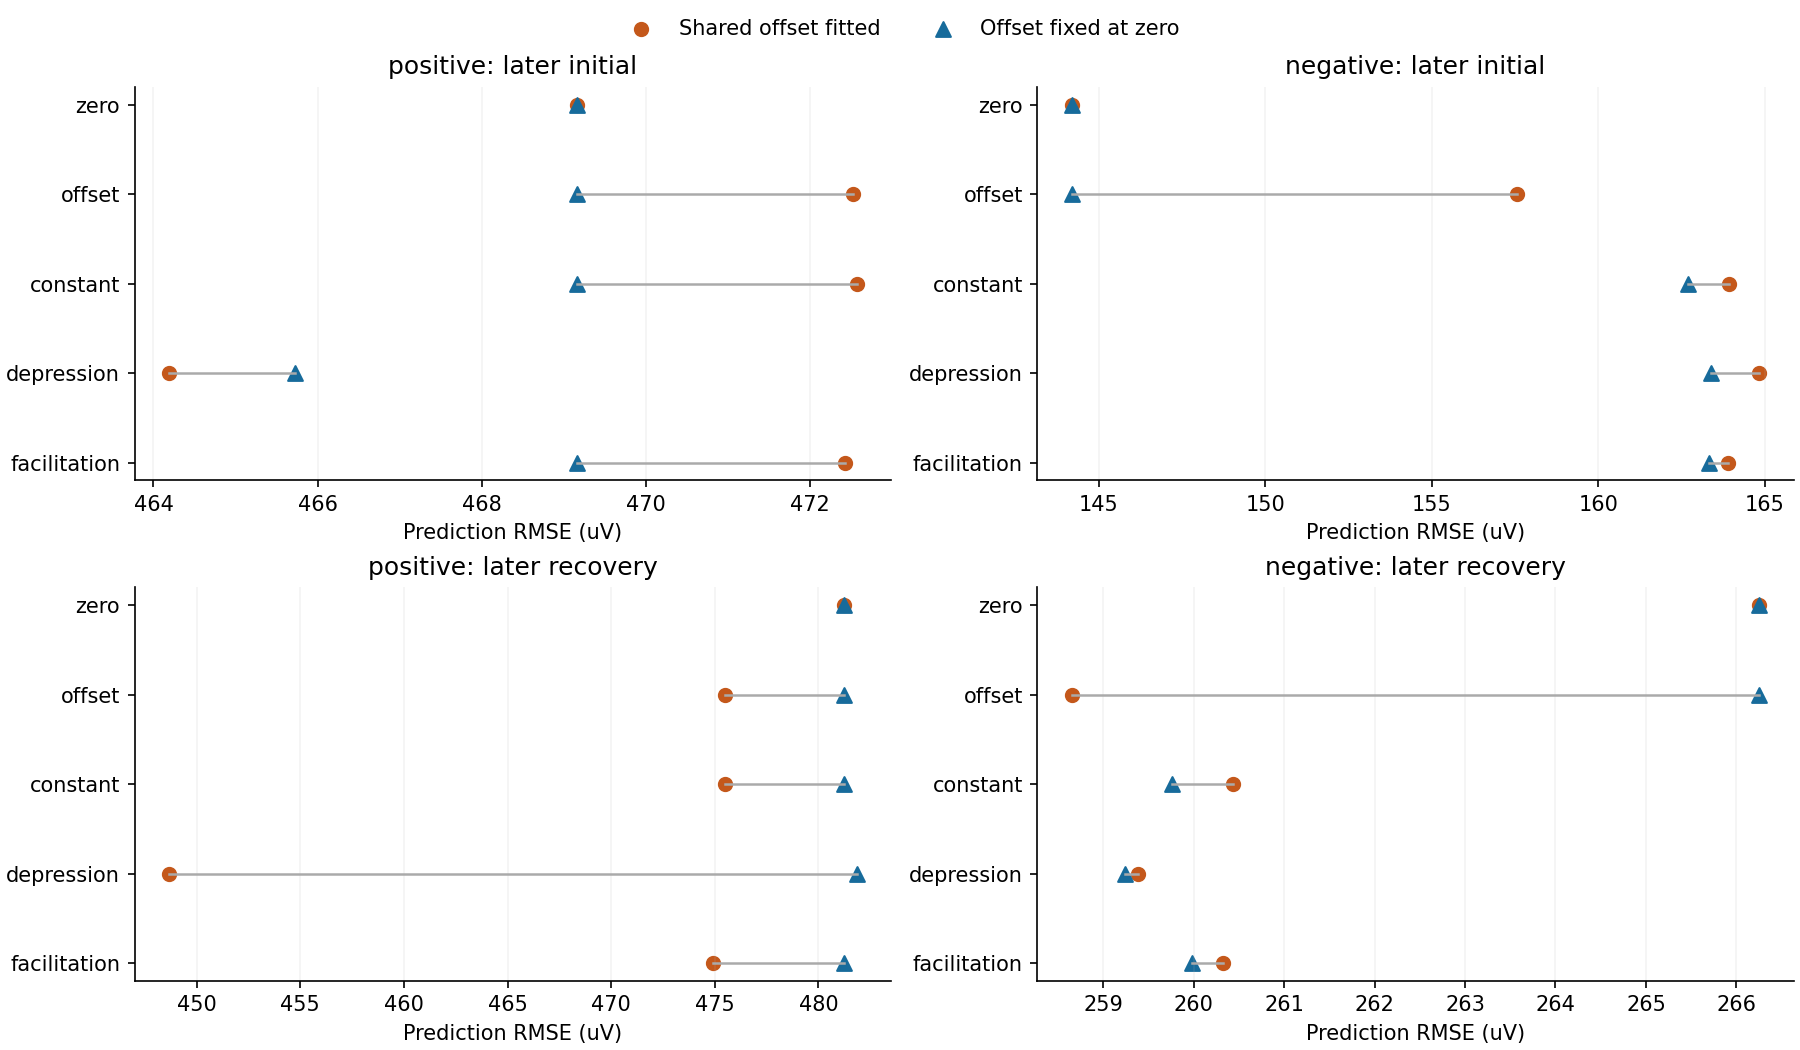

In [6]:
fig,axes = plt.subplots(2,2,figsize=(12,7),layout='constrained')
methods = ('zero','offset','constant','depression','facilitation')
for row_index,region in enumerate(('initial','recovery')):
    for col,target in enumerate(('positive','negative')):
        ax = axes[row_index,col]
        selected = {r['method']:r for r in sensitivity['comparisons'] if r['target']==target and r['region']==region and r['cohort']=='temporal'}
        free = np.array([selected[m]['shared_offset_rmse_uV'] for m in methods])
        anchored = np.array([selected[m]['anchored_rmse_uV'] for m in methods])
        y = np.arange(len(methods))
        for i in y:
            ax.plot([free[i],anchored[i]],[i,i],color='#AAAAAA',linewidth=1.2)
        ax.scatter(free,y,color='#C4581B',s=40,label='Shared offset fitted')
        ax.scatter(anchored,y,color='#176B9B',marker='^',s=50,label='Offset fixed at zero')
        ax.set_yticks(y,methods)
        ax.invert_yaxis()
        ax.set(title=f'{target}: later {region}',xlabel='Prediction RMSE (uV)')
        ax.grid(axis='x',alpha=.15)
handles,labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles,labels,loc='outside upper center',ncol=2,frameon=False)
figure = folder/'figures/recovery_waveform_offset_sensitivity.png'
fig.savefig(figure,dpi=150)
display(Image(filename=str(figure)))
plt.close(fig)


## Takeaways
The delayed difference-of-exponentials kernel has frequency response proportional to
\(e^{-i\omega\ell}(\tau_d-\tau_r)/[(1+i\omega\tau_d)(1+i\omega\tau_r)]\).
Time delay, filtering and residual overlap are therefore linked to frequency phase.
The source AP-to-target-voltage kernel mixes transmission, membrane and measurement
effects. Its fitted phase is not a calibrated synaptic delay or target impedance.

Depression uses a reduced resource recurrence; facilitation is a phenomenological
candidate. Prediction comparisons cannot on their own identify the biological
mechanism, long-term learning or a change in the Riemannian metric. Variable-gap
holdouts have at most one record per gap and are earlier in recording time.


The positive model's recovery advantage depends on the baseline assumption.
Anchoring b=0 removes that advantage, and the selected decay/recovery constants
change substantially. Preserve the free-offset gain as a bounded predictive result;
do not interpret it as identified plasticity. The flat fixed-filter training profile
does not establish a robust phase estimate; the 1% band is not a confidence interval.
